# Cement NPV summary

Run the cement Monte Carlo mean NPV, deterministic NPV, and Monte Carlo ranking summaries. This notebook displays figures inline only; it does not save figures or CSV files.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_deterministic import calculate_deterministic_cement_results
from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_cement_results,
)
from cement.cement_npv_summary_figures import (
    CEMENT_TECHNOLOGY_LABELS,
    calculate_cement_npv_rankings_from_results,
)
from npv_summary_plots import plot_average_rank_bars, plot_mean_npv_technology_bars


## Settings

In [2]:
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE
TECHNOLOGIES = tuple(CEMENT_TECHNOLOGY_LABELS)

pd.options.display.float_format = "{:,.3f}".format


## Monte Carlo mean NPV

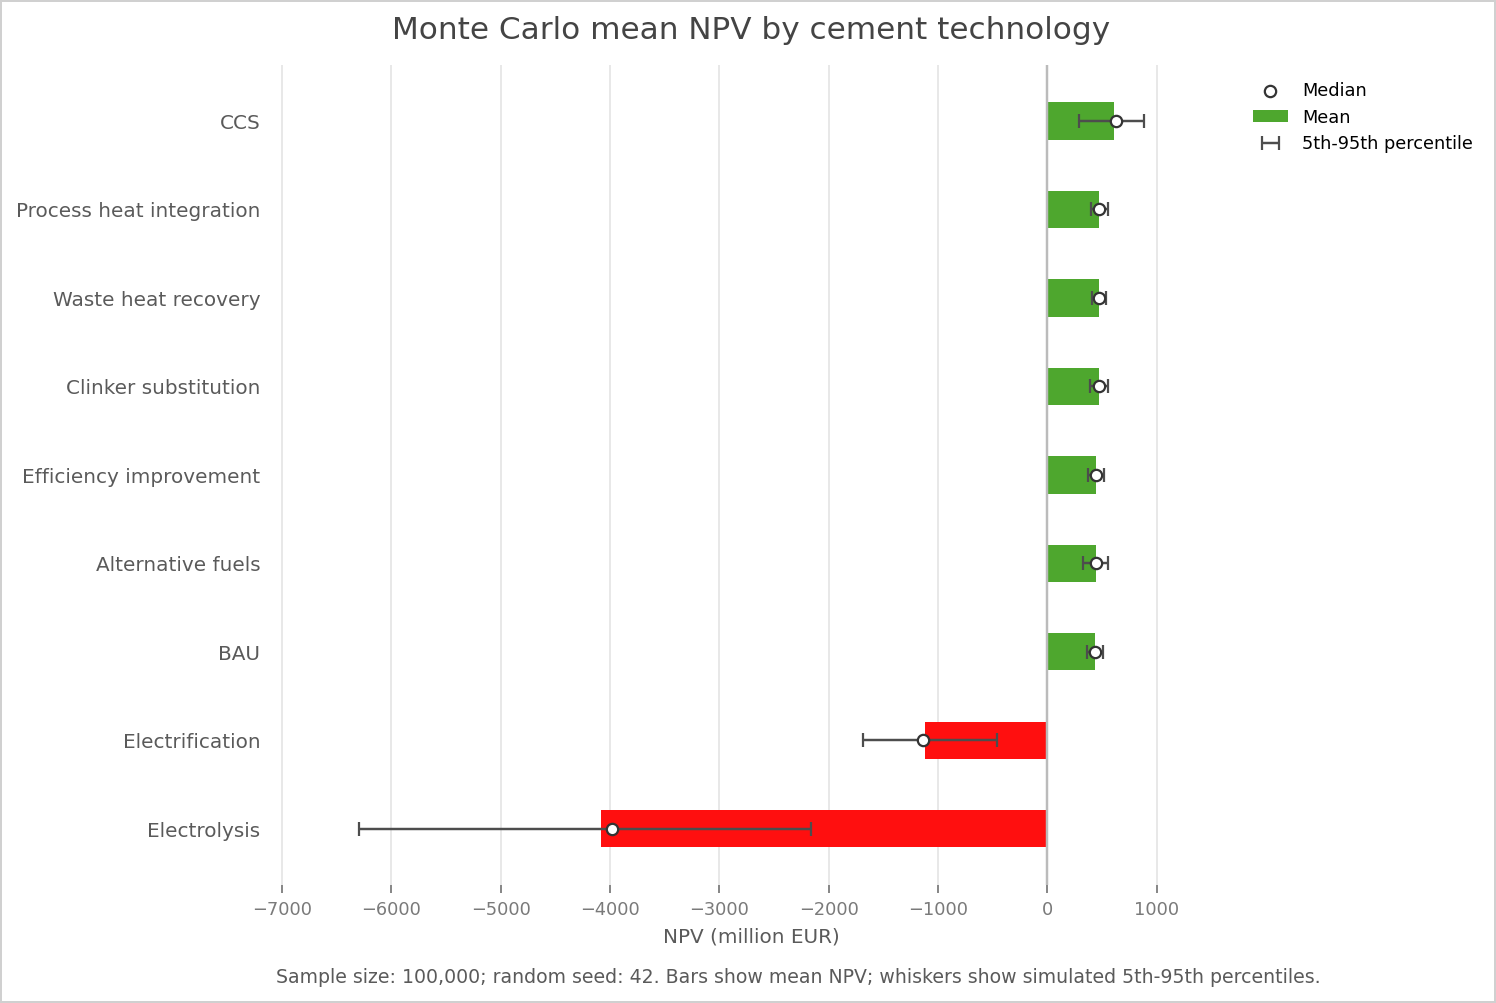

In [3]:
monte_carlo_results = simulate_cement_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=TECHNOLOGIES,
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)

mc_summary_rows = []
for technology, results in monte_carlo_results.items():
    values = np.asarray(results["npv_eur"], dtype=float) / 1_000_000
    per_t_values = np.asarray(results["npv_eur_per_t"], dtype=float)
    mc_summary_rows.append(
        {
            "label": CEMENT_TECHNOLOGY_LABELS.get(technology, technology),
            "technology_type": str(np.asarray(results["technology_type"])[0]),
            "mean_m_eur": values.mean(),
            "median_m_eur": np.median(values),
            "p05_m_eur": np.percentile(values, 5),
            "p95_m_eur": np.percentile(values, 95),
            "mean_eur_per_t": per_t_values.mean(),
        }
    )
mc_summary = pd.DataFrame(mc_summary_rows).sort_values("mean_m_eur", ascending=False)
mc_summary_by_label = mc_summary.set_index("label")

plot_mean_npv_technology_bars(
    values_million_eur=mc_summary_by_label["mean_m_eur"].to_dict(),
    output_path=None,
    title="Monte Carlo mean NPV by cement technology",
    median_values_million_eur=mc_summary_by_label["median_m_eur"].to_dict(),
    lower_values_million_eur=mc_summary_by_label["p05_m_eur"].to_dict(),
    upper_values_million_eur=mc_summary_by_label["p95_m_eur"].to_dict(),
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
)
plt.show()


## Deterministic NPV

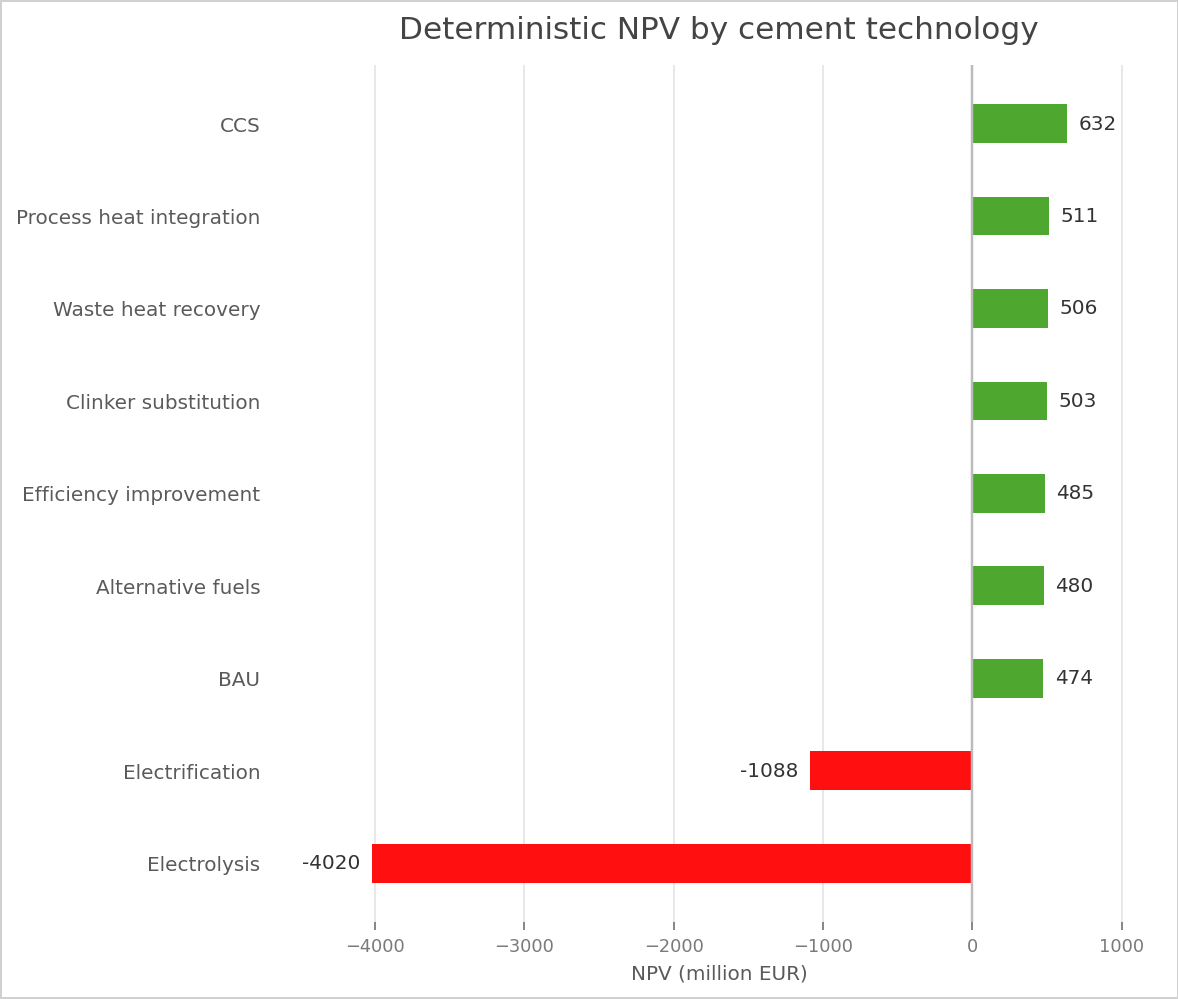

In [4]:
deterministic_results = calculate_deterministic_cement_results(technologies=TECHNOLOGIES)
det_summary_rows = []
for technology, results in deterministic_results.items():
    det_summary_rows.append(
        {
            "label": CEMENT_TECHNOLOGY_LABELS.get(technology, technology),
            "technology_type": str(np.asarray(results["technology_type"])[0]),
            "npv_m_eur": float(np.asarray(results["npv_eur"]).item()) / 1_000_000,
            "npv_eur_per_t": float(np.asarray(results["npv_eur_per_t"]).item()),
        }
    )
det_summary = pd.DataFrame(det_summary_rows).sort_values("npv_m_eur", ascending=False)

plot_mean_npv_technology_bars(
    values_million_eur=det_summary.set_index("label")["npv_m_eur"].to_dict(),
    output_path=None,
    title="Deterministic NPV by cement technology",
)
plt.show()


## Monte Carlo NPV ranking

,Technology,Average rank,Probability rank 1,Probability top 3,Simulations
0,CCS,2.311,0.718,0.773,100000
1,Process heat integration,3.071,0.074,0.659,100000
2,Waste heat recovery,3.285,0.063,0.570,100000
3,Clinker substitution,3.568,0.067,0.529,100000
4,Alternative fuels,4.798,0.076,0.350,100000
5,Efficiency improvement,4.938,0.003,0.117,100000
6,BAU,6.028,0.000,0.002,100000
7,Electrification,8.000,0.000,0.000,100000
8,Electrolysis,9.000,0.000,0.000,100000


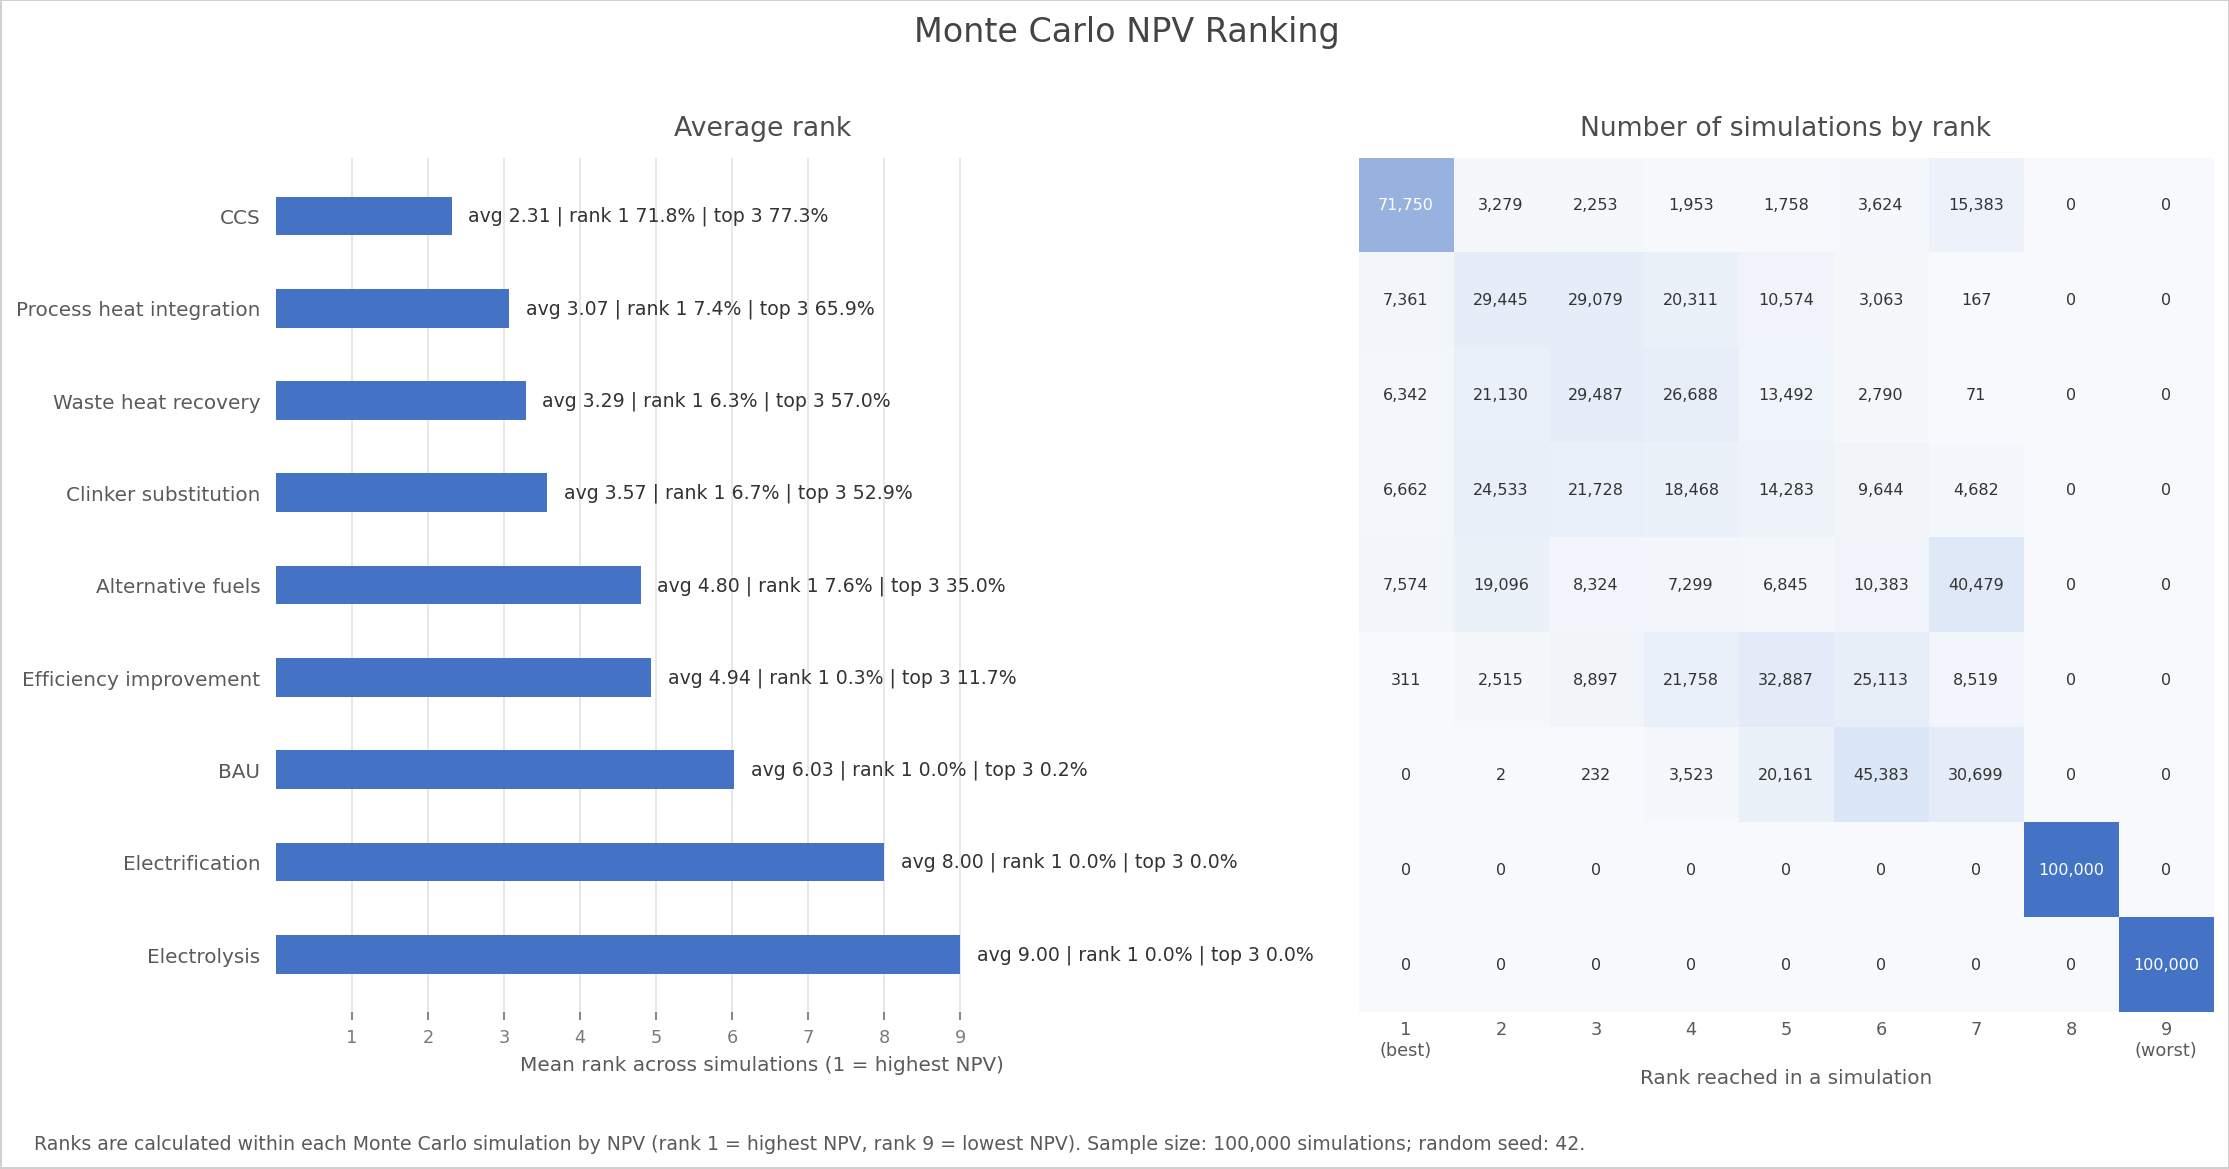

In [5]:
ranking_raw, ranking_summary = calculate_cement_npv_rankings_from_results(
    results=monte_carlo_results,
    sector_name="Cement",
)

ranking_summary_for_plot = ranking_summary.assign(
    display_label=ranking_summary["technology"].map(CEMENT_TECHNOLOGY_LABELS).fillna(ranking_summary["technology"])
)
rank_table = (
    ranking_summary_for_plot.rename(columns={"display_label": "Technology"})
    .loc[:, ["Technology", "average_rank", "probability_rank_1", "probability_top_3", "n_simulations"]]
    .rename(
        columns={
            "average_rank": "Average rank",
            "probability_rank_1": "Probability rank 1",
            "probability_top_3": "Probability top 3",
            "n_simulations": "Simulations",
        }
    )
)
display(rank_table)
plot_average_rank_bars(
    ranking_summary=ranking_summary_for_plot,
    output_path=None,
    title="Monte Carlo NPV Ranking",
    random_seed=RANDOM_SEED,
)
plt.show()
